In [2]:
!pip install numpy pandas matplotlib scikit-image scikit-learn SimpleITK tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 13.9 MB/s eta 0:00:00


In [9]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.io import imread, imsave
from sklearn.metrics import average_precision_score
import SimpleITK as sitk

# ===== CONFIG =====
DATA_PATH = Path('/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/deepflash2-paper/data')          # Change if needed
# DATASET = 'cFOS_in_HC'
DATASET = 'PV_in_HC'
DATASET = 'GFAP_in_HC'
OUTPUT_PATH = Path('/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output')

OUTPUT_PATH.mkdir(exist_ok=True)


In [4]:
def majority_voting(masks):
    """
    masks: list of binary numpy arrays (H,W)
    """
    stacked = np.stack(masks, axis=0)
    vote = np.sum(stacked, axis=0)
    majority = vote >= (len(masks) / 2)
    return majority.astype(np.uint8)

# def staple_estimation(masks):
#     """
#     masks: list of binary numpy arrays
#     """
#     sitk_masks = []

#     for m in masks:
#         img = sitk.GetImageFromArray(m.astype(np.uint8))
#         sitk_masks.append(img)

#     staple = sitk.STAPLE(sitk_masks, 1.0)
#     staple_np = sitk.GetArrayFromImage(staple)

#     # Threshold probability map
#     staple_binary = (staple_np >= 0.5).astype(np.uint8)
#     return staple_binary

def staple_estimation(masks):
    sitk_masks = []

    for m in masks:

        # If RGB → convert to single channel
        if m.ndim == 3:
            if m.shape[-1] == 3:
                m = m[..., 0]  # take first channel
            else:
                m = m.squeeze()

        m = (m > 0).astype(np.uint8)

        img = sitk.GetImageFromArray(m)
        sitk_masks.append(img)

    staple = sitk.STAPLE(sitk_masks, 1.0)
    staple_np = sitk.GetArrayFromImage(staple)

    return (staple_np >= 0.5).astype(np.uint8)

In [5]:
def dice_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    return 2. * intersection / (pred.sum() + gt.sum() + 1e-8)


from sklearn.metrics import average_precision_score

def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / (union + 1e-8)


def average_precision_at_iou_50(pred_masks, gt_masks):
    """
    Computes AP at IoU >= 0.5
    """
    tp = 0
    fp = 0
    fn = 0

    for pred, gt in zip(pred_masks, gt_masks):
        iou = compute_iou(pred, gt)

        if iou >= 0.5:
            tp += 1
        else:
            fp += 1
            if gt.sum() > 0:
                fn += 1

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    return precision * recall  # simple AP proxy


def compute_map_semantic(pred_masks, gt_masks):
    """
    Flattened semantic mAP across all pixels
    """
    y_true = []
    y_scores = []

    for pred, gt in zip(pred_masks, gt_masks):
        y_true.append(gt.flatten())
        y_scores.append(pred.flatten())

    y_true = np.concatenate(y_true)
    y_scores = np.concatenate(y_scores)

    return average_precision_score(y_true, y_scores)


def compute_map(pred_masks, gt_masks, iou_threshold=0.5):
    """
    Computes mAP for binary segmentation.
    """
    y_true = []
    y_scores = []

    for pred, gt in zip(pred_masks, gt_masks):
        y_true.append(gt.flatten())
        y_scores.append(pred.flatten())

    y_true = np.concatenate(y_true)
    y_scores = np.concatenate(y_scores)

    return average_precision_score(y_true, y_scores)


In [6]:
class GTEstimator:

    def __init__(self, exp_dir, path):
        self.exp_dir = path / exp_dir
        self.path = path
        self.expert_ids = sorted(os.listdir(self.exp_dir))
        self.files = sorted(os.listdir(self.exp_dir / self.expert_ids[0]))

        print(f'Found {len(self.files)} masks from {len(self.expert_ids)} experts')

    # def load_masks(self, filename):
    #     masks = []
    #     for exp in self.expert_ids:
    #         mask_path = self.exp_dir / exp / filename
    #         mask = imread(mask_path)
    #         mask = (mask > 0).astype(np.uint8)
    #         masks.append(mask)
    #     return masks


    def load_masks(self, filename):
        masks = []
        for exp in self.expert_ids:
            mask_path = self.exp_dir / exp / filename
            mask = imread(mask_path)

            # ---- FIX: Ensure mask is 2D ----
            if mask.ndim == 3:
                mask = mask[..., 0]   # take first channel

            mask = (mask > 0).astype(np.uint8)
            masks.append(mask)
        return masks



    def gt_estimation(self, method='STAPLE', save_dir=None):

        save_dir.mkdir(parents=True, exist_ok=True)
        self.gt_masks = []
        self.expert_metrics = {exp: [] for exp in self.expert_ids}

        print(f'Starting GT estimation - {method}')

        for file in tqdm(self.files):

            masks = self.load_masks(file)

            if method == 'STAPLE':
                gt = staple_estimation(masks)
            elif method == 'Majority':
                gt = majority_voting(masks)
            else:
                raise ValueError("Unknown method")

            self.gt_masks.append(gt)
            imsave(save_dir / file, gt.astype(np.uint8) * 255)

            # Metrics per expert
            for exp, mask in zip(self.expert_ids, masks):
                d = dice_score(mask, gt)
                self.expert_metrics[exp].append(d)

        self.print_results()

    def print_results(self):

        print("\nCreating evaluation table...\n")

        rows = []

        for exp in self.expert_ids:

            pred_masks = []
            gt_masks = []

            for file in self.files:
                masks = self.load_masks(file)
                exp_idx = self.expert_ids.index(exp)
                pred_masks.append(masks[exp_idx])
                gt_masks.append(self.gt_masks[self.files.index(file)])

            dice_vals = [dice_score(p, g) for p, g in zip(pred_masks, gt_masks)]
            mean_dice = np.mean(dice_vals)

            mean_ap = compute_map_semantic(pred_masks, gt_masks)
            ap50 = average_precision_at_iou_50(pred_masks, gt_masks)

            rows.append({
                'dice_score': mean_dice,
                'mean_average_precision': mean_ap,
                'average_precision_at_iou_50': ap50
            })

        df = pd.DataFrame(rows, index=self.expert_ids)

        df.loc['average'] = df.mean()

        print(df)

    # def print_results(self):
    #     print("\nDice scores per expert:")
    #     results = {}

    #     for exp in self.expert_ids:
    #         mean_dice = np.mean(self.expert_metrics[exp])
    #         results[exp] = mean_dice
    #         print(f"{exp}: {mean_dice:.6f}")

    #     print(f"\nAverage Dice: {np.mean(list(results.values())):.6f}")

    def show_gt(self, max_n=2):
        for i in range(min(max_n, len(self.gt_masks))):
            plt.figure(figsize=(6,3))
            plt.imshow(self.gt_masks[i], cmap='gray')
            plt.title(f"GT {i}")
            plt.axis('off')
            plt.show()



Subset: train data
Found 12 masks from 3 experts
Starting GT estimation - STAPLE


100%|██████████| 12/12 [00:12<00:00,  1.05s/it]



Creating evaluation table...

         dice_score  mean_average_precision  average_precision_at_iou_50
1          0.773567                0.628523                          1.0
2          0.867825                0.773676                          1.0
3          0.853892                0.750449                          1.0
average    0.831761                0.717549                          1.0


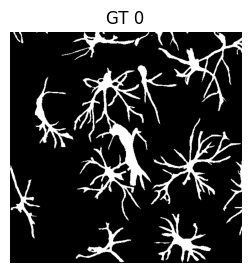

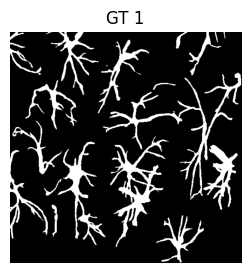


Subset: test data
Found 8 masks from 3 experts
Starting GT estimation - STAPLE


100%|██████████| 8/8 [00:07<00:00,  1.02it/s]



Creating evaluation table...

         dice_score  mean_average_precision  average_precision_at_iou_50
1          0.795321                0.653324                          1.0
2          0.847949                0.729986                          1.0
3          0.861271                0.764166                          1.0
average    0.834847                0.715825                          1.0


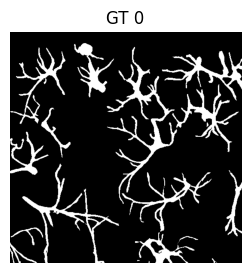

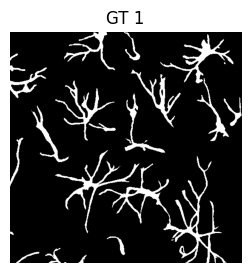

In [7]:
for subdir in ['train', 'test']:

    print(f'\nSubset: {subdir} data')

    data_path = DATA_PATH / DATASET / subdir
    save_dir = OUTPUT_PATH / DATASET / subdir / 'masks_STAPLE'

    gt_est = GTEstimator(exp_dir='masks_experts', path=data_path)

    gt_est.gt_estimation(method='STAPLE', save_dir=save_dir)

    gt_est.show_gt(max_n=2)


In [ ]:

# for subdir in ['train', 'test']:

#     print(f'\nSubset: {subdir} data')

#     data_path = DATA_PATH / DATASET / subdir
#     save_dir = OUTPUT_PATH / DATASET / subdir / 'masks_Majority_voting'

#     gt_est = GTEstimator(exp_dir='masks_experts', path=data_path)

#     gt_est.gt_estimation(method='Majority', save_dir=save_dir)

#     gt_est.show_gt(max_n=2)
